In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')


In [2]:
def SdH_amplitude(T, mstar, B):
    chi = 2 * np.pi**2 * k_B * T * mstar * m_e / (hbar * e * B)
    return chi / np.sinh(chi)

def Beff(Blo, Bhi):
    # Harmonic mean of Blo and Bhi
    return 2 / (1/Blo + 1/Bhi)



In [3]:
# from turtle import fillcolor

# import scipy.optimize
# label_spacer = 0.04

# peak_color = 'tab:green'

# def do_mass_fit(fig, axes, files, n_nom, D_nom, target_f=lambda x: 1, bg_subtract=None, plot_cbar=False, plot_xlabels=True, plot_ylabels=False):
#     Vtg, Vbg = calculate_gate_voltages(n_nom, D_nom, dtg=rmg19['experimental']['dtg'], dbg=rmg19['experimental']['dbg'])
#     n, D = calculate_n_D(Vtg, Vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
#     target_f = target_f(n)
#     popts, pcovs = [], []
#     contact_pair = 2
#     ffts = []
#     freqs = []
#     temps = []
#     temp_cmap = plt.cm.plasma 
#     temp_norm = plt.Normalize(vmin=25, vmax=450)
#     sdh_peaks = []
#     cb_width = 0.12
#     y_offset = 0.5
#     for file in files:
#         # load in the new data
#         data = sl.pload(file_path, file)
#         mc_0 = data['measurement_config']
#         md = sl.load_meta(file_path, file)
#         xs = data['xs']
#         I = data['sr830_4_X']
#         Vxx = data[f'sr830_{contact_pair}_X']
#         zs = Vxx/I

        
#         invB_range = np.max(1/xs) - np.min(1/xs)
#         num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/xs))))) *2
#         temp = np.nanmean(data['T']) * 1e3

#         # Get the fft
#         padding = 8
#         if bg_subtract == 'linear':
#             zs_detrended, bg = detrend_poly(xs, zs, degree=1)
#         elif bg_subtract == 'butter':
#             zs_detrended, bg = detrend_butterworth(xs, zs, cutoff=1, order=4)
#         elif bg_subtract == None:
#             zs_detrended = zs - np.mean(zs)
#         else:
#             raise ValueError("Invalid Background Subtraction Scheme")
        
#         interp_invB, interp_zs = interp_rxx(xs, zs_detrended, nx=num_invB_pts)

#         # rxx = interp_zs - np.mean(interp_zs)
#         rxx = interp_zs
#         fft, freq_b = make_vec_fft(interp_invB, rxx, n=n, padding=padding, return_complex=True, normalize=False)
#         ffts.append(fft[:len(freq_b)//2] / len(freq_b) ) 
#         freqs.append(freq_b[:len(freq_b)//2])
#         temps.append(temp)
        
        
      

#     freqs = np.array(freqs)
#     ffts = np.array(ffts)

#     # plot3 - fft with temperature colormap
#     ax = axes[0]
#     temps = np.array(temps)     
#     # Plot each curve with color based on temperature
#     epsilon = 0.2 if target_f >= 1 else 0.08

#     for i, (fft, freq_b, temp) in enumerate(zip(ffts, freqs, temps)):
#         # fft = fft/np.amax(ffts[0])
#         color = temp_cmap(temp_norm(temp))
#         plot = ax.plot(freq_b*n, np.abs(fft), linewidth=1, color=color, label=f'{temp:.2f} K')
        
#         peak_mask = (target_f - epsilon < freq_b) & (freq_b < target_f + epsilon)
#         # peaks = find_peaks(np.abs(fft[peak_mask]),
#         #     threshold_abs=1,
#         #     min_distance=30,
#         # )
        
#         top_peak = np.argmax(np.abs(fft[peak_mask]))                
#         f0 = freq_b[peak_mask][top_peak]
#         y0 = np.abs(fft)[peak_mask][top_peak]
#         sdh_peaks.append((f0, y0))
#         ax.plot(f0*n, y0, 
#             # 'x', color=peak_color, 
#             'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3, alpha=0.75, markeredgewidth=1,
#             # markersize=3
#         )
#     sdh_peaks = np.array(sdh_peaks)
#     # Add colorbar
#     if plot_cbar:
#         sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
#         sm.set_array([])
#         pos = ax.get_position()
#         cax = fig.add_axes([pos.x1 - cb_width - 0.2, pos.y1 + 0.02, cb_width, 0.01])
#         cb = plt.colorbar(sm, ax=ax, cax=cax, label='Temperature (mK)', orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
#         cb.ax.set_xlabel('Temperature (mK)',labelpad=5, x=0.3)
#         cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
#         cb.ax.xaxis.set_label_position('top')    

#     # ax.vlines(target_f*n, 0, 6e3, color='k', linestyle='dashed', alpha = 0.7)
   
#     if plot_xlabels:
#         ax.set_xlabel(r'$n_{\mathrm{SdH}}$')
#     xlo, xhi = 0, 0.6
#     ax.set_xlim(xlo, xhi)
#     # ax.set_ylim(0, np.max(sdh_peaks[:,1])*1.1)
#     ax.set_ylim(0, 6)
#     ax.set_yscale('linear')
#     # ax.set_ylim(1e-4, 1e-1)
#     # ax.set_yscale('log')

#     if plot_ylabels:
#          ax.set_ylabel(r'FFT amp. (a.u.)', y=y_offset)

#     ax3 = axes[1]
#     sdh_peaks = np.array(sdh_peaks)
#     ax3.plot(temps, sdh_peaks[:,1]/sdh_peaks[0,1], 'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3, label='Normalized SDH peak')
    
#     if plot_ylabels:
#         ax3.set_ylabel('Peak amp. (a.u.)', y=y_offset, rotation=270, labelpad=15)
#         ax3.yaxis.set_label_position("right")

#     B_eff = Beff(xs[0], xs[-1])
#     def fit_func(T, mstar):
#         return (SdH_amplitude(T, mstar, B_eff) /
#                 SdH_amplitude(temps[0]/1e3, mstar, B_eff))

#     popt, pcov = scipy.optimize.curve_fit(
#         fit_func, 
#         temps/1e3, 
#         sdh_peaks[:,1]/sdh_peaks[0,1], 
#         p0=[1],
#         bounds = (0, 10)
#     )
#     popts.append(popt)
#     pcovs.append(pcov)
#     print(np.max(temps))
#     if plot_xlabels:
#         ax3.set_xlabel('Temperature (mK)')
#     ax3.set_ylim(-0.05, 1.55)

#     for ax in axes:
#         ax.grid(True)
#     nstr  = r"$10^{12}$ cm$^{-2}$"
#     axes[1].set_title(f'$n={n:.2f}$ ({nstr})', x=-0.25, y=1.2)
#     return popts, pcovs, n

# n_filemap = {
#     # 0.80: np.arange(1708, 1714),
#     # 0.76: np.arange(1672, 1676),  
#     # 0.75: np.arange(1744, 1750), 
#     0.70: np.arange(1750, 1756),
#     0.65: np.arange(1756, 1762),
#     0.60: np.arange(1762, 1768),
#     0.55: np.arange(1768, 1774),
#     0.50: np.arange(1738, 1744),
# }
# fig = plt.figure(figsize=(7.5, 6))
# n_files = len(n_filemap)
# gs = GridSpec(n_files, 2, wspace=0.4, hspace=1.0)
# # fig, axes = plt.subplots(1, 3, figsize=(9*1.618, 3))
# all_axes = [ 
#     [fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(n_files)
# ]
# all_axes = np.array(all_axes)

# all_mstars = np.zeros(len(n_filemap))
# stdevs = np.zeros(len(n_filemap))
# ns_calc = np.zeros(len(n_filemap))

# for i, (n, files) in enumerate(n_filemap.items()):
#     masses, pcovs, n_calc = do_mass_fit(fig, all_axes[i, :2], n_filemap[n], n_nom = n, D_nom = 1, target_f = lambda x: 0.1, bg_subtract= None, 
#         plot_cbar=i==0, plot_xlabels=i==n_files-1,
#         plot_ylabels = i == 2,
#     )
#     all_mstars[i] = np.ravel(masses).item()   # NumPy>=2: no implicit (1,)->scalar
#     stdevs[i] = np.ravel(np.sqrt(pcovs)).item()
#     ns_calc[i] = n_calc
 

# # for i, ax in enumerate(np.ravel(all_axes)):
# #     pos = ax.get_position()
# #     fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, chr(97+i), fontweight='bold')


# plt.savefig('figS_QO_T_twotone_low.pdf', dpi=600, bbox_inches='tight',
#             pad_inches=0.02, transparent=False)


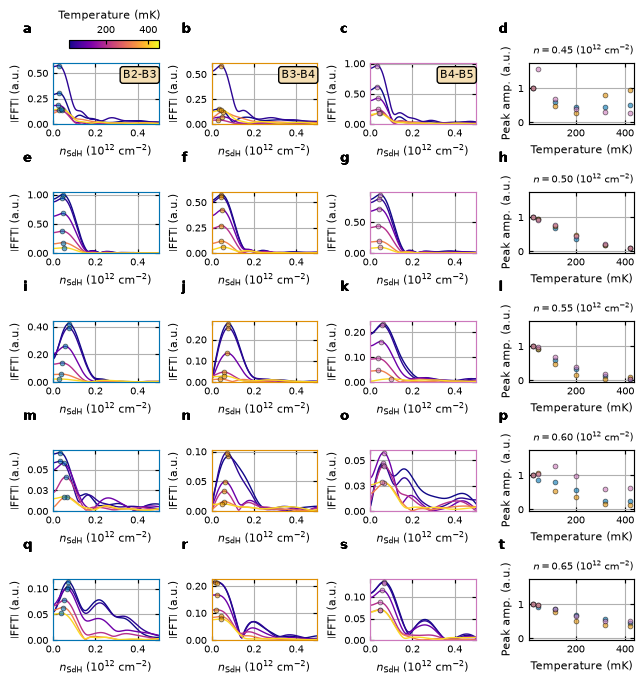

In [4]:
label_spacer = 0.04
# peak_colors = [
#     '#1F7A1F',
#     '#2B4C9B',
#     '#A0352B'
# ]
peak_colors = [x for x in contact_colors.values()]

def do_mass_fit(fig, axes, files, n_nom, D_nom, target_f=lambda x: 1, bg_subtract=None, plot_cbar=False, plot_xlabels=True, plot_ylabels=False, plot_title=True, contact_pair = 2, contact_labels=False):
    Vtg, Vbg = calculate_gate_voltages(n_nom, D_nom, dtg=rmg19['experimental']['dtg'], dbg=rmg19['experimental']['dbg'])
    n, D = calculate_n_D(Vtg, Vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    target_f = target_f(n)
    popts, pcovs = [], []
    peak_color = peak_colors[contact_pair-1]
    ffts = []
    freqs = []
    temps = []
    temp_cmap = plt.cm.plasma 
    temp_norm = plt.Normalize(vmin=25, vmax=450)
    sdh_peaks = []
    cb_width = 0.12
    y_offset = 0.5
    for file in files:
        # load in the new data
        data = sl.pload(file_path, file)
        mc_0 = data['measurement_config']
        md = sl.load_meta(file_path, file)
        xs = data['xs']
        I = data['sr830_4_X']
        Vxx = data[f'sr830_{contact_pair}_X']
        zs = Vxx/I

        
        invB_range = np.max(1/xs) - np.min(1/xs)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/xs))))) *2
        temp = np.nanmean(data['T']) * 1e3

        # Get the fft
        padding = 8
        if bg_subtract == 'linear':
            zs_detrended, bg = detrend_poly(xs, zs, degree=1)
        elif bg_subtract == 'quadratic':
            zs_detrended, bg = detrend_poly(xs, zs, degree=2)
        elif bg_subtract == 'butter':
            zs_detrended, bg = detrend_butterworth(xs, zs, cutoff=0.228*10, order=2)
        elif bg_subtract == None:
            zs_detrended = zs - np.mean(zs)
        else:
            raise ValueError("Invalid Background Subtraction Scheme")
        
        interp_invB, interp_zs = interp_rxx(xs, zs_detrended, nx=num_invB_pts)

        # rxx = interp_zs - np.mean(interp_zs)
        rxx = interp_zs
        
        fft, freq_b = make_vec_fft(interp_invB, rxx, n=n, padding=padding, return_complex=True, normalize=False)
        ffts.append(fft[:len(freq_b)//2] / len(freq_b) ) 
        freqs.append(freq_b[:len(freq_b)//2])
        temps.append(temp)
        
        
      

    freqs = np.array(freqs)
    ffts = np.array(ffts)

    # plot3 - fft with temperature colormap
    ax = axes[0]
    
    for spine in ax.spines.values():
        spine.set_edgecolor(contact_colors_idx[contact_pair])    
    if contact_labels:
        # box = mpatches.FancyBboxPatch(
        #     (0.7, 0.75),  # (x, y) in axes coordinates
        #     0.3, 0.25,      # width, height in axes coordinates
        #     boxstyle="round,pad=0.01",
        #     transform=ax.transAxes,
        #     facecolor='white',
        #     edgecolor='black',
        #     linewidth=1
        # )
        # ax.add_patch(box)
        ax.text(0.82, 0.8, contact_names[contact_pair], 
            transform=ax.transAxes,
            ha='center', va='center',
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#f5dfb4",
                edgecolor="k",
                linewidth=1,
                alpha=1,
            ) ,
            fontsize=8
        )

    temps = np.array(temps)     
    # Plot each curve with color based on temperature
    # epsilon = 0.2 if target_f >= 1 else 0.08
    epsilon = 0.4

    for i, (fft, freq_b, temp) in enumerate(zip(ffts, freqs, temps)):
        # fft = fft/np.amax(ffts[0])
        color = temp_cmap(temp_norm(temp))
        plot = ax.plot(freq_b*n, np.abs(fft), linewidth=1, color=color, label=f'{temp:.2f} K')
        
        peak_mask = (target_f - epsilon < freq_b) & (freq_b < target_f + epsilon)
        # peaks = find_peaks(np.abs(fft[peak_mask]),
        #     threshold_abs=1,
        #     min_distance=30,
        # )
        
        top_peak = np.argmax(np.abs(fft[peak_mask]))                
        f0 = freq_b[peak_mask][top_peak]
        y0 = np.abs(fft)[peak_mask][top_peak]
        sdh_peaks.append((f0, y0))
        ax.plot(f0*n, y0, 
            # 'x', color=peak_color, markersize=3
            'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
            zorder = 999
        )
    sdh_peaks = np.array(sdh_peaks)
    # Add colorbar
    if plot_cbar:
        sm = plt.cm.ScalarMappable(cmap=temp_cmap, norm=temp_norm)
        sm.set_array([])
        pos = ax.get_position()
        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.02, cb_width, 0.01])
        cb = plt.colorbar(sm, ax=ax, cax=cax, label='Temperature (mK)', orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
        cb.ax.set_xlabel('Temperature (mK)',labelpad=5, x=0.45)
        cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
        cb.ax.xaxis.set_label_position('top')    


    # ax.vlines(target_f*n, 0, 6e3, color='k', linestyle='dashed', alpha = 0.7)
   
    if plot_xlabels:
        ax.set_xlabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
        # ax.set_xlabel(r'$n_{\mathrm{SdH}}/n$ ($10^{12}$ cm$^{-2}$)')
    xlo, xhi = 0, 0.5
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(0, np.max(sdh_peaks[:,1])*1.05)

    # ax.set_ylim(0, 5)
    ax.set_yscale('linear')
    # ax.set_ylim(1e-4, 1e-1)
    # ax.set_yscale('log')

    if plot_ylabels:
         ax.set_ylabel(r'$\left|\mathrm{FFT}\right|$ (a.u.)', y=y_offset)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax3 = axes[1]
    sdh_peaks = np.array(sdh_peaks)
    ax3.plot(temps, sdh_peaks[:,1]/sdh_peaks[0,1], 
        # 'x', color=peak_color, markersize=3, 
        'o', markerfacecolor=peak_color, markeredgecolor='k', markersize=3.5, alpha=0.6, markeredgewidth=0.5,
        label='Normalized SDH peak',
    )
    
    if plot_ylabels:
        # ax3.set_ylabel('Peak amp. (a.u.)', y=y_offset, rotation=270, labelpad=15)
        # ax3.yaxis.set_label_position("right")
        ax3.set_ylabel('Peak amp. (a.u.)')

    B_eff = Beff(xs[0], xs[-1])
    def fit_func(T, mstar):
        return (SdH_amplitude(T, mstar, B_eff) /
                SdH_amplitude(temps[0]/1e3, mstar, B_eff))

    popt, pcov = scipy.optimize.curve_fit(
        fit_func, 
        temps/1e3, 
        sdh_peaks[:,1]/sdh_peaks[0,1], 
        p0=[1],
        bounds = (0, 10)
    )
    popts.append(popt)
    pcovs.append(pcov)

    if plot_xlabels:
        ax3.set_xlabel('Temperature (mK)')
    ax3.set_ylim(-0.05, 1.75)

    for ax in axes:
        ax.grid(True)
    nstr  = r"$10^{12}$ cm$^{-2}$"
    if plot_title:
        axes[1].set_title(f'$n = {n:.2f}$ ({nstr})', y=1.00,
            # bbox=dict(
            #     boxstyle="round,pad=0.25",
            #     facecolor="lightblue",
            #     edgecolor="navy",
            #     linewidth=1,
            #     alpha=0.9,
            #     ) 
            loc='right',
            fontsize=7,
        )
    return popts, pcovs, n

n_filemap = {
    # 0.80: np.arange(1708, 1714),
    # 0.76: np.arange(1672, 1676),  
    # 0.75: np.arange(1744, 1750), 
    0.70: np.arange(1750, 1756),
    0.65: np.arange(1756, 1762),
    0.60: np.arange(1762, 1768),
    0.55: np.arange(1768, 1774),
    0.50: np.arange(1738, 1744),
}
n_filemap = dict(reversed(n_filemap.items()))


fig = plt.figure(figsize=(7.5, 7.5))
n_files = len(n_filemap)
gs = GridSpec(n_files, 4, wspace=0.5, hspace=1.1)
# fig, axes = plt.subplots(1, 3, figsize=(9*1.618, 3))
all_axes = [ 
    [fig.add_subplot(gs[i, j]) for j in range(4)] for i in range(n_files)
]
all_axes = np.array(all_axes)

all_mstars = np.zeros(len(n_filemap))
stdevs = np.zeros(len(n_filemap))
ns_calc = np.zeros(len(n_filemap))

for i, (n, files) in enumerate(n_filemap.items()):
    for contact_idx, contact in contact_names.items():
        masses, pcovs, n_calc = do_mass_fit(fig, [all_axes[i,contact_idx-1], all_axes[i,3]], n_filemap[n], 
            n_nom = n, D_nom = 1, target_f = lambda x: 0.2/x, bg_subtract= 'linear', 
            plot_cbar=i==0 and contact_idx==1, 
            # plot_xlabels=i==n_files-1,
            plot_xlabels=True,
            plot_ylabels = True,
            plot_title = contact_idx ==2,
            contact_pair = contact_idx,
            contact_labels = i==0,
        )
        all_mstars[i] = np.ravel(masses).item()   # NumPy>=2: no implicit (1,)->scalar
        stdevs[i] = np.ravel(np.sqrt(pcovs)).item()
        ns_calc[i] = n_calc
 

    for i, ax in enumerate(np.ravel(all_axes)):
        pos = ax.get_position()
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, chr(97+i), fontweight='bold')


plt.savefig('figS_QO_T_twotone_low_v2.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.05, transparent=False)

